In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(
    "OnlineRetail.csv",
    encoding="latin1"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df[(df["Quantity"] > 0 ) & (df["UnitPrice"] > 0) ] 

In [14]:
df = df.dropna(
    subset=["CustomerID"]
)

In [15]:
df["Revenue"] = (
    df["Quantity"]
    *
    df["UnitPrice"]
)

In [16]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [17]:
# creating new dataframe from original df 
customer_df = df.groupby(
    "CustomerID"
).agg({

    "Revenue":"sum", # how much moey this customer has spent 

    "InvoiceNo":"nunique", #count the number of unique invoice numbers 

    "Quantity":"sum" #add all the quantities by a a customer 

}).reset_index()

In [18]:
print(customer_df.columns)

Index(['CustomerID', 'Revenue', 'InvoiceNo', 'Quantity'], dtype='object')


In [19]:
customer_df.columns = [

    "CustomerID",

    "TotalRevenue",

    "TotalOrders",

    "TotalQuantity"
]

In [20]:
print(customer_df.columns)

Index(['CustomerID', 'TotalRevenue', 'TotalOrders', 'TotalQuantity'], dtype='object')


In [21]:
customer_df.head()

,CustomerID,TotalRevenue,TotalOrders,TotalQuantity
0,12346.0,77183.60,1,74215
1,12347.0,4310.00,7,2458
2,12348.0,1797.24,4,2341
3,12349.0,1757.55,1,631
4,12350.0,334.40,1,197


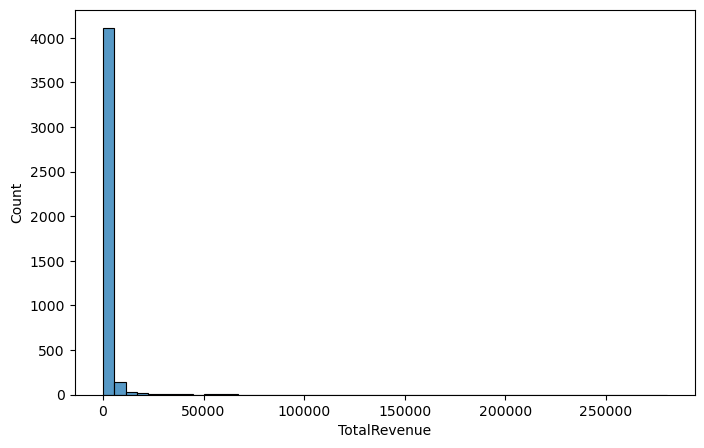

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(
    customer_df["TotalRevenue"],
    bins=50
)

plt.show()

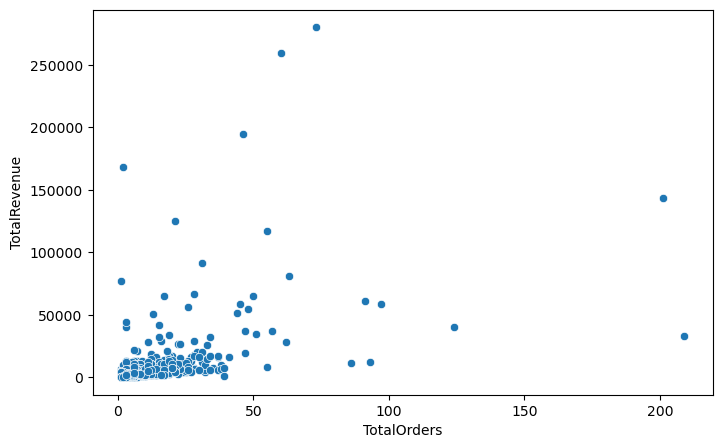

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="TotalOrders",
    y="TotalRevenue",
    data=customer_df
)
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler
X = customer_df[
    [
        "TotalRevenue",
        "TotalOrders",
        "TotalQuantity"
    ]
]
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

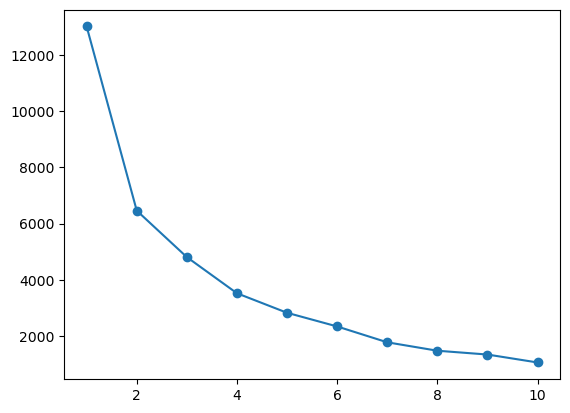

In [24]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.show()

In [25]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

customer_df["Cluster"] = kmeans.fit_predict(
    X_scaled
)

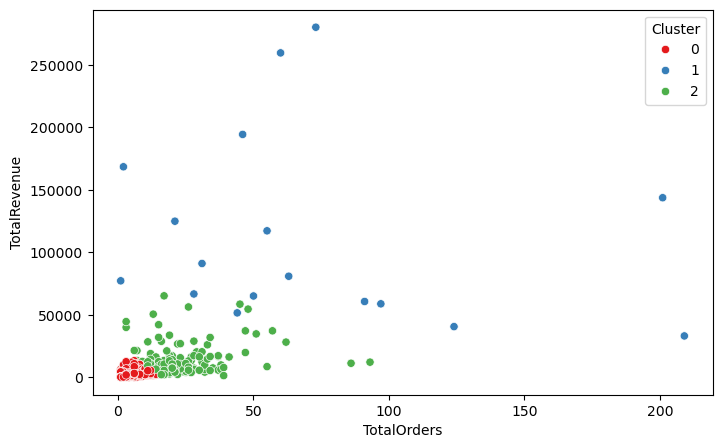

In [36]:
plt.figure(figsize=(8,5))

sns.scatterplot(

    x="TotalOrders",

    y="TotalRevenue",

    hue="Cluster",

    data=customer_df,

    palette="Set1"
)

plt.show()

In [27]:
from sklearn.metrics import silhouette_score
score = silhouette_score(
    X_scaled,
    customer_df["Cluster"]
)

print(score)

0.8120837189321943


In [28]:
# Business Insights

# After clustering:

# Cluster 0
# VIP Customers
# Highest Revenue

# Highest Orders
# Cluster 1
# Regular Customers

# Moderate Spending
# Cluster 2
# Low Value Customers
# Low Revenue
# Low Engagement